In [2]:
import pandas as pd
import glob

files = glob.glob("../data/raw/grid_search/*.csv")

runs = {}

for f in files:
    df = pd.read_csv(f)
    runs[f] = df

print(f"Liczba runów: {len(runs)}")

Liczba runów: 432


## Methodology

To systematically investigate the conditions under which speciation emerges in the simulated population, we performed a comprehensive parameter sweep using a Cartesian product of key model parameters.

### Parameter Space Exploration

The following parameters were varied:

- Mutation probability per individual:  
  **μ ∈ {0.005, 0.01, 0.05}**

- Mutation step size (standard deviation):  
  **ξ ∈ {0.001, 0.05, 0.1}**

- Selection strength (fitness function width):  
  **σ ∈ {0.2, 0.5, 1.0, 2.0}**

- Environmental change rate:  
  **c ∈ {0.0, 0.002, 0.005, 0.01}**

- Number of generations:  
  **T ∈ {50, 100, 200}**

All possible combinations of these parameters were generated using a Cartesian product, resulting in a total of:

\[
3 \times 3 \times 4 \times 4 \times 3 = 432
\]

independent simulation runs.

---

### Simulation Setup

Each simulation was initialized with:

- Population size: **N = 100**
- Phenotype dimensionality: **n = 5**
- Initial population distributed around the environmental optimum
- A linearly shifting environment defined by parameter **c**

For each parameter combination:

1. A new population was initialized
2. The environment dynamics were defined
3. Mutation, selection, and reproduction strategies were applied iteratively
4. The simulation was run for **T generations**

---

### Data Collection

During each simulation, statistics were recorded at every generation, including:

- Mean fitness
- Phenotypic variance
- Distance from environmental optimum
- Number of clusters (via KMeans clustering)
- Silhouette score (cluster separation quality)

Each simulation produced a separate output file, enabling detailed post hoc analysis.

---

### Objective of Analysis

The primary goal of this analysis is to identify:

- Under which parameter configurations speciation emerges
- How quickly speciation occurs (speciation time)
- Which parameters most strongly influence diversification dynamics

By exploring a broad parameter space, we aim to uncover the relationships between mutation, selection, environmental change, and the emergence of distinct phenotypic clusters.

Subsequent sections present statistical analyses and visualizations derived from this dataset.

In [3]:
def detect_speciation_time(df, silhouette_threshold=0.9, min_duration=30):
    """
    Zwraca pierwsze pokolenie, gdzie stabilna specjacja zachodzi.
    """
    condition = (
        (df["n_clusters"] >= 2) &
        (df["silhouette"] > silhouette_threshold)
    )

    count = 0

    for i, val in enumerate(condition):
        if val:
            count += 1
            if count >= min_duration:
                return i - min_duration + 1  # początek stabilnej specjacji
        else:
            count = 0

    return None  # brak specjacji

results = []

for fname, df in runs.items():
    t_spec = detect_speciation_time(df)

    # wyciąganie parametrów z nazwy pliku
    import re
    params = dict(re.findall(r"(mu|xi|sigma|c|T)([0-9\.]+)", fname))

    results.append({
        "file": fname,
        "mu": float(params.get("mu", 0)),
        "xi": float(params.get("xi", 0)),
        "sigma": float(params.get("sigma", 0)),
        "c": float(params.get("c", 0)),
        "generations": float(params.get("T", 0)),
        "speciation_time": t_spec,
        "speciated": t_spec is not None
    })

df_spec = pd.DataFrame(results)
print(df_spec)


                                                  file    mu     xi  sigma  \
0    ../data/raw/grid_search/run_mu0.01_xi0.1_sigma...  0.01  0.100    2.0   
1    ../data/raw/grid_search/run_mu0.05_xi0.05_sigm...  0.05  0.050    2.0   
2    ../data/raw/grid_search/run_mu0.05_xi0.05_sigm...  0.05  0.050    0.2   
3    ../data/raw/grid_search/run_mu0.01_xi0.1_sigma...  0.01  0.100    0.5   
4    ../data/raw/grid_search/run_mu0.05_xi0.1_sigma...  0.05  0.100    0.2   
..                                                 ...   ...    ...    ...   
427  ../data/raw/grid_search/run_mu0.01_xi0.001_sig...  0.01  0.001    0.5   
428  ../data/raw/grid_search/run_mu0.01_xi0.001_sig...  0.01  0.001    0.5   
429  ../data/raw/grid_search/run_mu0.05_xi0.05_sigm...  0.05  0.050    0.2   
430  ../data/raw/grid_search/run_mu0.05_xi0.1_sigma...  0.05  0.100    0.2   
431  ../data/raw/grid_search/run_mu0.01_xi0.05_sigm...  0.01  0.050    0.5   

         c  generations  speciation_time  speciated  
0    0.00

### Detection of Speciation Events

To identify the emergence of speciation in each simulation run, we defined a quantitative criterion based on clustering structure and its stability over time.

For each generation, two conditions were evaluated:

- The population must form at least **two distinct clusters**:
  \[
  n_{\text{clusters}} \geq 2
  \]

- The clustering quality must exceed a predefined threshold based on the silhouette score:
  \[
  \text{silhouette} > 0.9
  \]

The silhouette score measures how well-separated clusters are, with values close to 1 indicating strong separation.

---

### Stability Criterion

To avoid detecting transient or noisy clustering as speciation, we introduced a temporal stability requirement:

- The above conditions must be satisfied for at least **30 consecutive generations**

This ensures that only persistent and well-separated phenotypic clusters are classified as speciation events.

---

### Speciation Time

For each simulation, the **speciation time** was defined as:

> the first generation at which the stability criterion is satisfied

If no such period was found, the simulation was classified as **non-speciating**.

---

### Implementation

The detection was implemented as a sequential scan over generations:

- A boolean condition was evaluated at each time step
- A counter tracked consecutive generations satisfying the condition
- Once the counter reached the required duration (30), the starting generation was recorded as the speciation time

If the condition was never met for a sufficiently long period, the result was set to `None`.

---

### Output Data

For each simulation run, the following summary statistics were extracted:

- Parameter values: \( \mu, \xi, \sigma, c, T \)
- Speciation time (if detected)
- Binary indicator of speciation occurrence

These results were stored in a structured table for further statistical analysis.

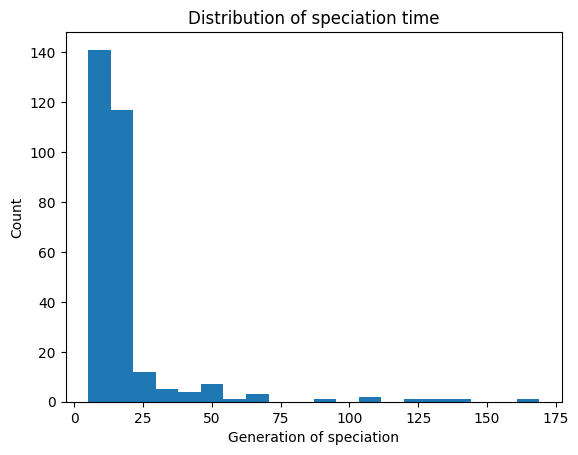

1
2


In [4]:
import matplotlib.pyplot as plt

df_valid = df_spec[df_spec["speciation_time"].notnull()]

plt.hist(df_valid["speciation_time"], bins=20)
plt.xlabel("Generation of speciation")
plt.ylabel("Count")
plt.title("Distribution of speciation time")
plt.show()
print(df_valid["speciated"].nunique())
print(df_spec["speciated"].nunique())

### Distribution of Speciation Time

The distribution of speciation time across simulations reveals a highly non-uniform pattern. Most speciation events occur early in the simulation, within the first ~20 generations, indicating rapid divergence of the population under these parameter configurations.

In contrast, a small subset of simulations exhibits delayed speciation, with speciation occurring at much later stages (around 150 generations). This suggests the existence of distinct dynamical regimes:

- **Early speciation regime**, characterized by rapid formation of stable clusters.
- **Delayed speciation regime**, where divergence emerges only after prolonged evolutionary dynamics.

The observed multimodal distribution indicates that speciation timing is strongly dependent on the underlying parameter configuration and does not follow a continuous distribution across the explored parameter space.

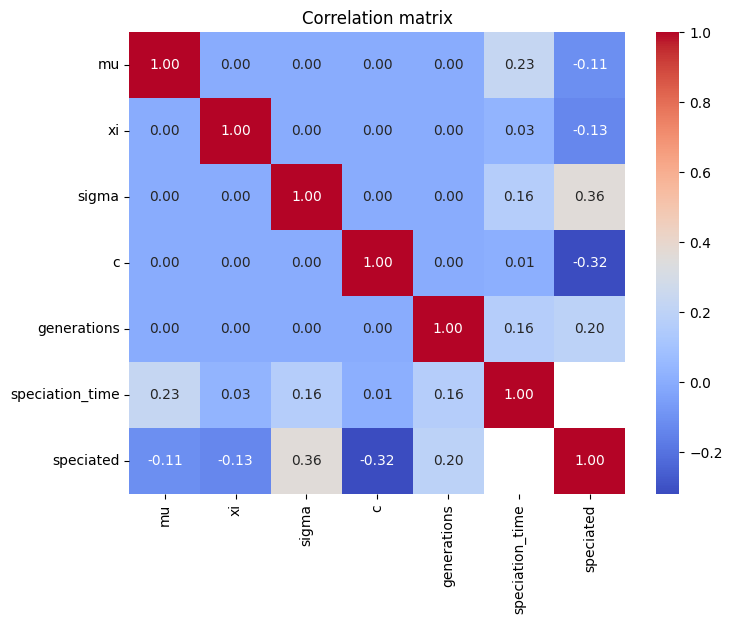

In [5]:
corr = df_spec.corr(numeric_only=True, method="spearman")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

### Correlation Analysis (Spearman)

To investigate monotonic relationships between model parameters and speciation-related outcomes, Spearman rank correlation was computed and visualized using a heatmap.

The analysis revealed several notable relationships:

- The environmental change rate parameter (**c**) shows a **negative correlation** with the occurrence of speciation (ρ ≈ -0.32).  
  This indicates that faster environmental changes tend to inhibit the emergence of speciation. In other words, as the rate of environmental change increases, the likelihood of stable cluster formation decreases.

- The selection strength parameter (**σ**) is **positively correlated** with speciation time (ρ ≈ 0.36).  
  This suggests that stronger selection pressures are associated with delayed speciation events. Higher σ values may slow down the divergence process, requiring more generations for distinct clusters to stabilize.

- The mutation rate (**μ**) shows a weaker positive correlation with speciation time (ρ ≈ 0.23), indicating that higher mutation rates may slightly delay the emergence of stable speciation.

- The mutation step size (**ξ**) and number of generations (**T**) both exhibit weak positive correlations with speciation time (ρ ≈ 0.16 for both), suggesting a limited but observable influence on the timing of speciation.

Overall, the correlation analysis suggests that environmental dynamics (c) and selection strength (σ) are the most influential parameters affecting speciation dynamics, while mutation-related parameters play a secondary role.

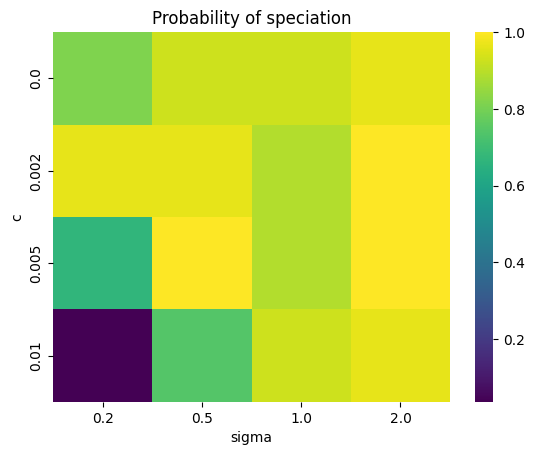

In [5]:
pivot = df_spec.pivot_table(
    values="speciated",
    index="c",
    columns="sigma",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis")
plt.title("Probability of speciation")
plt.show()

### Interaction Between Environmental Change (c) and Selection Strength (σ)

To better understand how environmental dynamics and selection strength jointly influence speciation, we computed the empirical probability of speciation across combinations of parameters \( c \) and \( \sigma \). The results were visualized using a heatmap of mean speciation occurrence.

The analysis reveals that speciation probability is not uniform across the parameter space, but instead depends strongly on the interaction between environmental change rate and selection strength.

The highest probability of speciation is observed for moderate values of environmental change (approximately \( c = 0.002 \) to \( c = 0.005 \)) combined with strong selection pressure (\( \sigma = 2.0 \)). In these regions, populations are most likely to split into distinct clusters.

In contrast, lower values of \( \sigma \) are generally associated with a reduced probability of speciation, regardless of the environmental change rate. This suggests that strong selection is a key driver facilitating population divergence.

Similarly, extreme values of the environmental change parameter (either very low or higher) appear to reduce the likelihood of speciation, indicating that an intermediate level of environmental dynamics is most conducive to diversification.

Overall, the results suggest a non-linear interaction between \( c \) and \( \sigma \), where speciation emerges most readily under a combination of moderate environmental change and strong selection pressure.

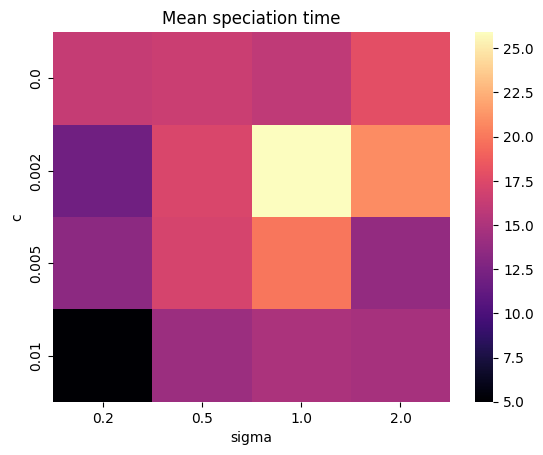

In [6]:
pivot_time = df_spec.pivot_table(
    values="speciation_time",
    index="c",
    columns="sigma",
    aggfunc="mean"
)

sns.heatmap(pivot_time, cmap="magma")
plt.title("Mean speciation time")
plt.show()

The analysis of speciation time reveals substantial heterogeneity across the parameter space. Rather than exhibiting a single global optimum, speciation time varies depending on specific combinations of environmental change rate (\( c \)) and selection strength (\( \sigma \)).

In particular, some parameter combinations (e.g., low selection strength with higher environmental change) lead to very rapid speciation, while other regions of the parameter space result in significantly delayed divergence.

This indicates that speciation dynamics are governed by nonlinear interactions between parameters, and cannot be attributed to the effect of any single parameter in isolation.

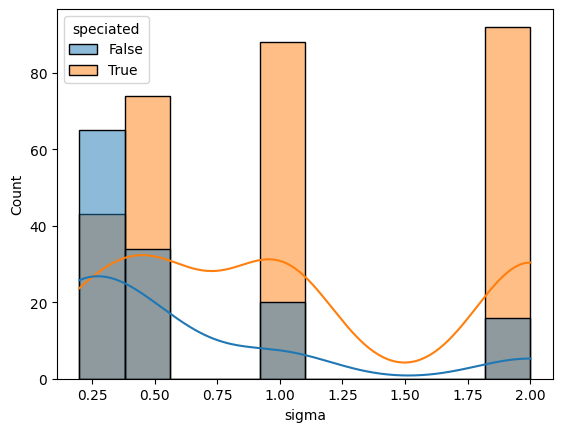

In [14]:
sns.histplot(data=df_spec, x="sigma", hue="speciated", kde=True)
plt.show()

The analysis indicates that higher values of selection strength (\( \sigma \)) are associated with an increased probability of speciation. This trend suggests that stronger selection promotes phenotypic divergence, facilitating the emergence of distinct clusters within the population.

In [8]:
from sklearn.linear_model import LogisticRegression

X = df_spec[["mu", "xi", "sigma", "c", "generations"]].fillna(0)
y = df_spec["speciated"].astype(int)

model = LogisticRegression()
model.fit(X, y)

print("Coefficients:")
for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

Coefficients:
mu -0.32484571393058653
xi -0.46648978081898274
sigma 1.8631718778541253
c -0.15576857542307218
generations 0.004960370257694208


To quantify the relative importance of model parameters on the probability of speciation, a logistic regression model was fitted using all experimental runs. The response variable indicated whether speciation occurred, while the predictors included mutation rate (\( \mu \)), parameter \( \xi \), selection strength (\( \sigma \)), environmental change rate (\( c \)), and number of generations.

The results indicate that selection strength (\( \sigma \)) is the most influential positive predictor of speciation, showing a strong positive coefficient. This suggests that stronger selection significantly increases the likelihood of population divergence.

In contrast, mutation rate (\( \mu \)) and parameter \( \xi \) exhibit negative coefficients, indicating that higher values of these parameters are associated with a reduced probability of speciation. This may be due to increased genetic variability preventing the formation of stable clusters.

The environmental change parameter (\( c \)) shows a mild negative effect in the linear model, although previous analyses suggest a more complex, non-linear relationship. This indicates that logistic regression may not fully capture interactions between parameters.

Finally, the number of generations has a negligible coefficient, suggesting that it does not independently influence the probability of speciation when other factors are controlled for.